# **Stock Return Risk Analyzer**


- importing essential libraries

In [51]:
import numpy as np
from numpy.typing import NDArray
import yfinance
import matplotlib.pyplot as plt




## 1. Load Prices

**Definition:**
Historical closing prices of a stock collected over a period of time.
Each value represents the final traded price of the stock on that day.


**Note:**
- Shape: `(trading_days,)`
- 252 trading days in a year (excludes weekends and holidays)



In [52]:
tickers = ["MSFT", "GOOG", "AMZN"]
data = yfinance.download(
    tickers=tickers, start="2025-01-01", end="2026-01-01", group_by="ticker"
)
essential_data  = (data.xs("Close", level=1, axis=1))

[*********************100%***********************]  3 of 3 completed


In [53]:
amazon = essential_data["AMZN"].to_numpy()
google = essential_data["GOOG"].to_numpy()
microsoft = essential_data["MSFT"].to_numpy()




## 2. Daily Returns

**Definition:**
The percentage change in a stock's price from one day to the next.
Returns normalize prices — making every stock comparable regardless of its price level.

**Formula:**
```
Rₜ = (Pₜ - Pₜ₋₁) / Pₜ₋₁

Rₜ   → return on day t
Pₜ   → closing price today
Pₜ₋₁ → closing price yesterday
```

**Example:**
```
Price day 1 : $150.00
Price day 2 : $152.00
Return      : (152 - 150) / 150 = +0.0133 = +1.33%
```


In [54]:
def retrun_percent(price: NDArray) -> NDArray:
    returns  =( price[1:] - price[:-1] )/ price[:-1]
    return returns



## 3. Annual Return

**Definition:**
The average daily return scaled up to represent a full year of performance.
Tells you how much profit a stock is expected to generate in one year.

**Formula:**
```
Annual Return = mean(Rₜ) × 252

mean(Rₜ) → average of all daily returns
252      → trading days in a year (fixed constant, not returns.size)
```

**Example:**
```
Daily returns : [+0.0133, -0.0197, +0.0269, -0.0131]
Daily mean    : 0.00183
Annual return : 0.00183 × 252 = 0.461 = 46.1%
```


In [55]:
def annual_return(returns : NDArray):
    annual_return_ = np.mean(returns) * 252
    return annual_return_

In [56]:
amazon_returns = retrun_percent(amazon)
google_returns = retrun_percent(google)
microsoft_returns = retrun_percent(microsoft)


annual_returns_amazon = annual_return(amazon_returns)
annual_returns_google = annual_return(google_returns)
annual_returns_microsoft = annual_return(microsoft_returns)
#  amazon 
print("\nAmazon")
print(f"Daily mean return :  {(amazon_returns.mean() * 100) :.6f} %") 
print(f"Annual return :  {(annual_returns_amazon * 100):.3f} %") 



#  googl
print("\nGoogle")
print(f"Daily mean return :  {(google_returns.mean() * 100) :.6f} %") 
print(f"Annual return :  {(annual_returns_google * 100):.3f} %") 


# microsoft
print("\nMicrosoft")
print(f"Daily mean return :  {(microsoft_returns.mean() * 100) :.6f} %") 
print(f"Annual return :  {(annual_returns_microsoft * 100):.3f} %") 




Amazon
Daily mean return :  0.042237 %
Annual return :  10.644 %

Google
Daily mean return :  0.222021 %
Annual return :  55.949 %

Microsoft
Daily mean return :  0.072496 %
Annual return :  18.269 %


- Google's Stock has the largest return rate

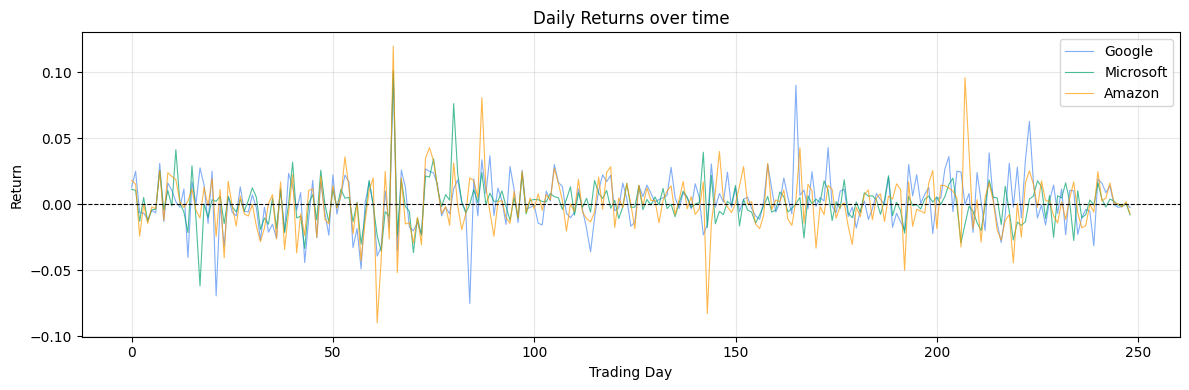

In [68]:
tickers = ['Google', 'Microsoft', 'Amazon']
colors  = ['#4C8BF5', '#00A36C', '#FF9900']
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(google_returns,    label='Google',    alpha=0.7, linewidth=0.8, color=colors[0])
ax.plot(microsoft_returns, label='Microsoft', alpha=0.7, linewidth=0.8, color=colors[1])
ax.plot(amazon_returns,    label='Amazon',    alpha=0.7, linewidth=0.8, color=colors[2])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily Returns over time')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

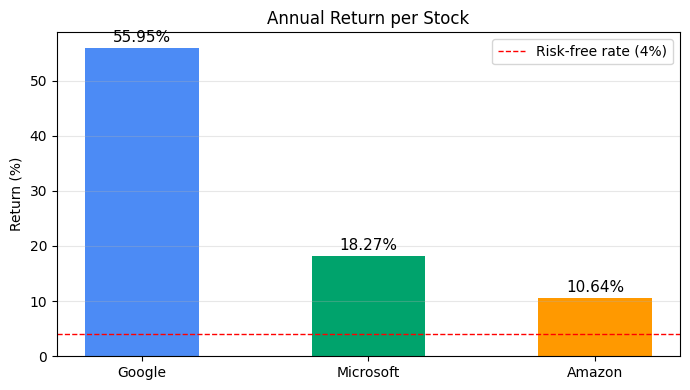

In [69]:
values = [annual_returns_google * 100,
          annual_returns_microsoft * 100,
          annual_returns_amazon * 100]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tickers, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11)

ax.axhline(4, color='red', linestyle='--', linewidth=1, label='Risk-free rate (4%)')
ax.set_title('Annual Return per Stock')
ax.set_ylabel('Return (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## 4. Annual Risk (Standard Deviation)

**Definition:**
Measures how much daily returns jump around from their average.
The more unpredictable a stock's returns, the higher its risk.
In finance, standard deviation = volatility = risk — all the same thing.

**Formula:**
```
σ_daily  = √ [ Σ(Rₜ - μ)² / (n - 1) ]
σ_annual = σ_daily × √252

μ    → mean daily return
n    → number of daily returns
n-1  → sample correction (ddof=1, not n)
```




**Interpretation:**
- Low risk  → stock moves smoothly and predictably
- High risk → stock swings wildly day to day

---


In [58]:
def annual_risk(returns : NDArray):
    daily_std = np.std(returns,ddof=1)
    annual_std  =daily_std * np.sqrt(252)
    return annual_std

In [59]:
risk_amazon    = annual_risk(amazon_returns)
risk_google    = annual_risk(google_returns)
risk_microsoft = annual_risk(microsoft_returns)

print("\nAmazon")
print(f"Annual Risk : {risk_amazon * 100:.3f} %")

print("\nGoogle")
print(f"Annual Risk : {risk_google * 100:.3f} %")

print("\nMicrosoft")
print(f"Annual Risk : {risk_microsoft * 100:.3f} %")


Amazon
Annual Risk : 34.489 %

Google
Annual Risk : 31.969 %

Microsoft
Annual Risk : 24.299 %


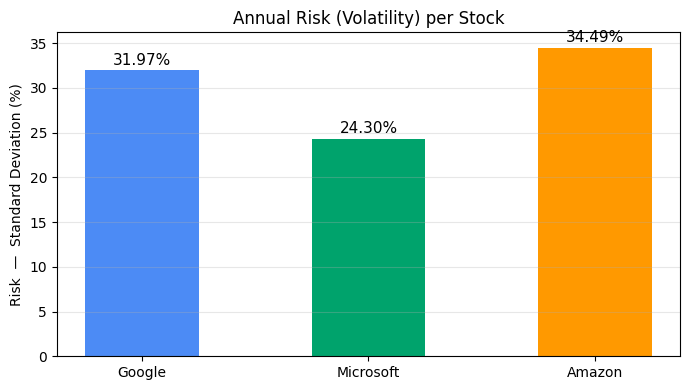

In [70]:
values = [risk_google * 100,
          risk_microsoft * 100,
          risk_amazon * 100]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tickers, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Annual Risk (Volatility) per Stock')
ax.set_ylabel('Risk  —  Standard Deviation (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Amazon's stock has the highest risk  , while microsoft is the most stable


## 5. Sharpe Ratio

**Definition:**
Measures how much extra return you earn per unit of risk taken.
The risk-free rate is what you would earn with zero risk (e.g. US Treasury bonds ≈ 4%).
Any stock must beat this to justify the risk of holding it.

**Formula:**
```
S = (E(Rₚ) - Rƒ) / σₚ

E(Rₚ) → annualized stock return
Rƒ    → risk-free rate (default = 0.04 = 4%)
σₚ    → annualized standard deviation (risk)
```

**Example:**
```
Stock A : return = 20%, risk = 15%  →  (0.20 - 0.04) / 0.15 = 1.07  ✓ Good
Stock B : return = 30%, risk = 40%  →  (0.30 - 0.04) / 0.40 = 0.65  ✗ Not rewarded
```
Stock A wins despite lower raw return — it earns more per unit of risk.

**Interpretation:**
```
S < 0      → worse than holding cash (Treasury bonds)
0  to 1   → acceptable but not great
1  to 2   → good
> 2        → excellent
```



In [60]:
def sharpe_ratio(annual_return: float  , annual_risk: float):
    risk_free = 0.04
    return (annual_return - risk_free) / annual_risk

In [61]:
sharpe_ratio_amazon = sharpe_ratio(annual_returns_amazon , risk_amazon)
sharpe_ratio_google = sharpe_ratio(annual_returns_google , risk_google)
sharpe_ratio_microsoft = sharpe_ratio(annual_returns_microsoft , risk_microsoft)




print(f"sharpe Ratio Amazom : {sharpe_ratio_amazon}")
print(f"sharpe Ratio Microsoft : {sharpe_ratio_microsoft}")
print(f"sharpe Ratio Google : {sharpe_ratio_google}")

sharpe Ratio Amazom : 0.19263201577355982
sharpe Ratio Microsoft : 0.5872337637865587
sharpe Ratio Google : 1.6249789252955378


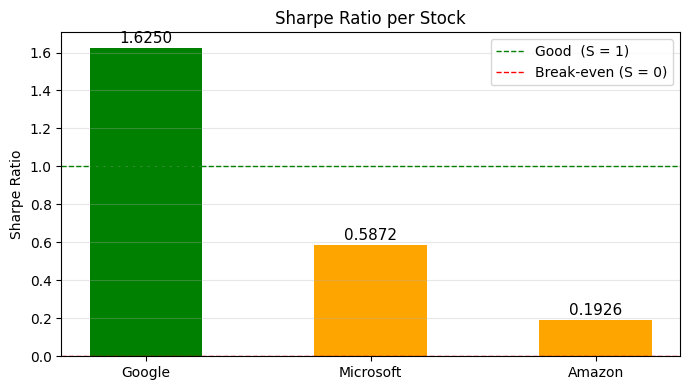

In [71]:
values      = [sharpe_ratio_google, sharpe_ratio_microsoft, sharpe_ratio_amazon]
bar_colors  = ['green' if s >= 1 else 'orange' if s >= 0 else 'red' for s in values]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tickers, values, color=bar_colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)

ax.axhline(1, color='green', linestyle='--', linewidth=1, label='Good  (S = 1)')
ax.axhline(0, color='red',   linestyle='--', linewidth=1, label='Break-even (S = 0)')
ax.set_title('Sharpe Ratio per Stock')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Google has highest sharpe ratio



## 6. Covariance Matrix

**Definition:**
Measures how two stocks move together over time.
A single stock has variance. Multiple stocks have covariance — the relationship between their movements.

**Formula:**
```
Cov(A, B) = [ Σ (Rₐ,ₜ - μₐ)(R_b,ₜ - μ_b) ] / (n - 1)  ×  252

Positive  → stocks rise and fall together      (less diversification)
Negative  → stocks move in opposite directions (more diversification)
Zero      → stocks are unrelated, independent
```

**Matrix structure (3 stocks):**
```
             Stock A    Stock B    Stock C
Stock A  [  Var(A)    Cov(A,B)  Cov(A,C) ]
Stock B  [ Cov(A,B)   Var(B)    Cov(B,C) ]
Stock C  [ Cov(A,C)  Cov(B,C)   Var(C)   ]

Diagonal     = each stock's own variance  →  σ² per stock
Off-diagonal = pairwise covariance        →  how two stocks co-move
```

**Reading the matrix:**
```
             Google    Microsoft    Amazon
Google   [ 0.1022      0.0331      0.0596 ]
Microsoft[ 0.0331      0.0590      0.0491 ]
Amazon   [ 0.0596      0.0491      0.1190 ]

Diagonal  → individual variances:
  Google    : √0.1022 = 31.97% annual risk
  Microsoft : √0.0590 = 24.29% annual risk  (most stable)
  Amazon    : √0.1190 = 34.50% annual risk  (most volatile)

Off-diagonal → all positive = all three move in the same direction
  (expected for stocks in the same sector)
```


In [62]:
def covariance(list_returns : list ) : 
    returns_matrix = np.column_stack(list_returns)
    cov = np.cov(returns_matrix.T) *252
    return cov

In [63]:
covariance_matrix = covariance([google_returns, microsoft_returns , amazon_returns])
print(f"Covariance : \n{covariance_matrix}")

Covariance : 
[[0.1022035  0.03313496 0.05962006]
 [0.03313496 0.05904296 0.04907744]
 [0.05962006 0.04907744 0.11895024]]


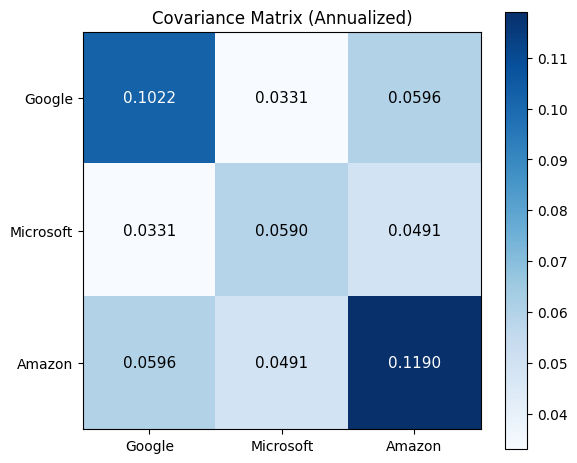

In [73]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(covariance_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{covariance_matrix[i, j]:.4f}',
                ha='center', va='center', fontsize=11,
                color='white' if covariance_matrix[i, j] > 0.08 else 'black')

ax.set_xticks([0, 1, 2]); ax.set_xticklabels(tickers)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(tickers)
ax.set_title('Covariance Matrix (Annualized)')
plt.tight_layout()
plt.show()



## 7. Portfolio Risk

**Definition:**
The overall risk of a portfolio holding multiple stocks with given weights.
Accounts for how stocks relate to each other — not just their individual risks.
This is why diversification works: combining stocks that don't move together reduces total risk.

**Formula:**
```
σₚ = √(wᵀ Σ w)

w  → weights vector       shape: (num_stocks,)   must sum to 1
Σ  → covariance matrix    shape: (num_stocks, num_stocks)
wᵀ → transpose of weights

Step 1: wᵀ × Σ   → shape (num_stocks,)   weighted sum of each column
Step 2: result × w → scalar               portfolio variance
Step 3: √ variance → portfolio std dev    (portfolio risk)
```



**Weights rule:**
```
weights must always sum to 1
equal weights for 3 stocks → [0.333, 0.333, 0.333]
```



In [64]:
def portfolio_risk(weights  : NDArray , cov_matrix: NDArray):
    var = weights @ cov_matrix @ weights
    portfolio_risk_ = np.sqrt(var)
    return portfolio_risk_


In [65]:
n = 3 
weights = np.ones(n) / n

p_risk = portfolio_risk(weights , covariance_matrix)

print(f"portfolio risk = {p_risk *100 :.3f} %")

portfolio risk = 25.030 %
